In [1]:
import os
import glob
import pandas as pd
import json
import osmnx as ox
from osmnx.graph import graph_from_point
import matplotlib.pyplot as plt
from shapely.geometry import LineString, Point
import geopandas as gpd
from tqdm import tqdm
import numpy

In [2]:
# read all csv file from the folder
folder_path = "/Users/stevenliao/Desktop/9101 project/data"
csv_files = glob.glob(os.path.join(folder_path, "*.csv"))
dataframes = {}

for file_path in csv_files:
    filename = os.path.basename(file_path)
    parts = filename.split("_")
    if len(parts) < 3:
        print(f"Skipping file with unexpected format: {filename}")
        continue

    date_str = parts[0]         
    location_str = parts[1]     
    start_time_str = parts[2]   

  
    monthday = date_str[4:]  
    loc_num = location_str.replace("d", "")
    loc_label = f"L{loc_num}"

    if start_time_str.startswith("0"):
        start_time_str = start_time_str[1:] 

    var_name = f"df_{loc_label}{start_time_str}_{monthday}"
    rows = []

    with open(file_path, 'r', encoding='utf-8') as f:
        next(f)  # skip header
        for line_num, line in enumerate(f, start=2):
            fields = line.strip().split(';')
            if len(fields) < 4:
                continue

            track_id    = fields[0]
            vehicle_type = fields[1]
            traveled_d  = fields[2]
            avg_speed   = fields[3]
            time_step_fields = fields[4:]

            while time_step_fields and not time_step_fields[-1].strip():
                time_step_fields.pop()

            leftover = len(time_step_fields) % 6
            if leftover != 0:
                time_step_fields = time_step_fields[:-leftover]

            n_blocks = len(time_step_fields) // 6
            for i in range(n_blocks):
                offset = i * 6
                lat     = time_step_fields[offset + 0]
                lon     = time_step_fields[offset + 1]
                speed   = time_step_fields[offset + 2]
                lon_acc = time_step_fields[offset + 3]
                lat_acc = time_step_fields[offset + 4]
                tstamp  = time_step_fields[offset + 5]

                rows.append({
                    "track_id":   track_id,
                    "type":       vehicle_type,
                    "traveled_d": traveled_d,
                    "avg_speed":  avg_speed,
                    "lat":        lat,
                    "lon":        lon,
                    "speed":      speed,
                    "lon_acc":    lon_acc,
                    "lat_acc":    lat_acc,
                    "time":       tstamp,
                    "time_step":  i
                })

    df = pd.DataFrame(rows)
    numeric_cols = ["traveled_d", "avg_speed", "lat", "lon", "speed", "lon_acc", "lat_acc", "time"]
    for col in numeric_cols:
        df[col] = pd.to_numeric(df[col], errors="coerce")
    dataframes[var_name] = df
    print(f"Parsed {filename} -> {var_name} with shape: {df.shape}")

# convert each dataFrame to JSON grouped by vehicle (track_id)
output_folder = "/Users/stevenliao/Desktop/9101 project/json_output"
os.makedirs(output_folder, exist_ok=True)

for var_name, df in dataframes.items():
    vehicle_dict = {}

    for track_id, group in df.groupby("track_id"):
        vehicle_dict[track_id] = {
            "track_id": track_id,
            "type": group["type"].iloc[0],
            "traveled_d": group["traveled_d"].iloc[0],
            "avg_speed": group["avg_speed"].iloc[0],
            "lat": group["lat"].tolist(),
            "lon": group["lon"].tolist(),
            "speed": group["speed"].tolist(),
            "lon_acc": group["lon_acc"].tolist(),  
            "lat_acc": group["lat_acc"].tolist(),
            "time": group["time"].tolist()
        }

    json_path = os.path.join(output_folder, f"{var_name}.json")
    with open(json_path, "w") as f:
        json.dump(vehicle_dict, f, indent=2)

    print(f"Saved JSON for {var_name} to {json_path}")

Parsed 20181024_d1_0830_0900.csv -> df_L1830_1024 with shape: (1446887, 11)
Parsed 20181024_d5_0830_0900.csv -> df_L5830_1024 with shape: (5081100, 11)
Parsed 20181024_d2_0830_0900.csv -> df_L2830_1024 with shape: (3761480, 11)
Parsed 20181024_d6_0830_0900.csv -> df_L6830_1024 with shape: (8328203, 11)
Parsed 20181024_d1_1030_1100.csv -> df_L11030_1024 with shape: (1491548, 11)
Parsed 20181024_d7_0830_0900.csv -> df_L7830_1024 with shape: (7428891, 11)
Parsed 20181024_d3_0830_0900.csv -> df_L3830_1024 with shape: (3366770, 11)
Parsed 20181024_d4_0830_0900.csv -> df_L4830_1024 with shape: (3659048, 11)
Parsed 20181024_d1_0900_0930.csv -> df_L1900_1024 with shape: (2042963, 11)
Parsed 20181024_d1_0930_1000.csv -> df_L1930_1024 with shape: (2165658, 11)
Parsed 20181024_d1_1000_1030.csv -> df_L11000_1024 with shape: (2915666, 11)
Saved JSON for df_L1830_1024 to /Users/stevenliao/Desktop/9101 project/json_output/df_L1830_1024.json
Saved JSON for df_L5830_1024 to /Users/stevenliao/Desktop/91

In [3]:
# to test adn check
if "df_L1830_1024" in dataframes:
    vehicle_summary = dataframes["df_L1830_1024"].groupby("track_id").agg({
        "type": "first",
        "speed": "mean",
        "traveled_d": "first",
        "avg_speed": "first"
    }).reset_index()

    vehicle_summary["track_id"] = pd.to_numeric(vehicle_summary["track_id"], errors="coerce")
    vehicle_summary = vehicle_summary.sort_values("track_id").reset_index(drop=True)
    print(vehicle_summary)

     track_id         type      speed  traveled_d  avg_speed
0           1          Car   9.890360       48.85   9.770344
1           2   Motorcycle  19.930437       98.09  19.839417
2           3   Motorcycle  18.233507       63.80  18.228752
3           4   Motorcycle  26.287781      145.72  26.229014
4           5   Motorcycle  24.920658      138.01  24.841425
..        ...          ...        ...         ...        ...
917       918          Car  30.982230       78.83  30.846243
918       919   Motorcycle   9.346298       19.50   9.234518
919       920          Car  24.612719       48.97  24.486209
920       921   Motorcycle  30.146401       46.68  30.007124
921       922          Car  23.489531       35.00  23.335533

[922 rows x 5 columns]


In [4]:
# check origin json 
json_path = "/Users/stevenliao/Desktop/9101 project/json_output/df_L1830_1024.json"

with open(json_path, "r") as f:
    data = json.load(f)

print(f"Number of vehicles: {len(data)}")

first_vehicle_id = next(iter(data))
print(f"Track ID: {first_vehicle_id}")
print(json.dumps(data[first_vehicle_id], indent=2))

Number of vehicles: 922
Track ID: 1
{
  "track_id": "1",
  "type": " Car",
  "traveled_d": 48.85,
  "avg_speed": 9.770344,
  "lat": [
    37.977391,
    37.977391,
    37.977391,
    37.97739,
    37.97739,
    37.977389,
    37.977389,
    37.977388,
    37.977388,
    37.977388,
    37.977387,
    37.977387,
    37.977386,
    37.977386,
    37.977385,
    37.977385,
    37.977384,
    37.977384,
    37.977384,
    37.977383,
    37.977383,
    37.977383,
    37.977382,
    37.977382,
    37.977382,
    37.977381,
    37.977381,
    37.977381,
    37.977381,
    37.977381,
    37.97738,
    37.97738,
    37.97738,
    37.97738,
    37.97738,
    37.97738,
    37.97738,
    37.97738,
    37.97738,
    37.97738,
    37.977379,
    37.977379,
    37.977379,
    37.977379,
    37.977379,
    37.977379,
    37.977379,
    37.977379,
    37.977379,
    37.977379,
    37.977379,
    37.977378,
    37.977378,
    37.977378,
    37.977378,
    37.977378,
    37.977378,
    37.977378,
    37.9

In [5]:
# this way runtime too long

#import osmnx as ox
#from osmnx.graph import graph_from_bbox
#df = dataframes["df_L1830_1024"]
#margin = 0.001
#north = df["lat"].max() + margin
#south = df["lat"].min() - margin
#east = df["lon"].max() + margin
#west = df["lon"].min() - margin

#print(f"Bounding box:\n  north={north:.6f}, south={south:.6f}, east={east:.6f}, west={west:.6f}")
#bbox = (north, south, east, west)
#G = graph_from_bbox(bbox=bbox, network_type="drive")




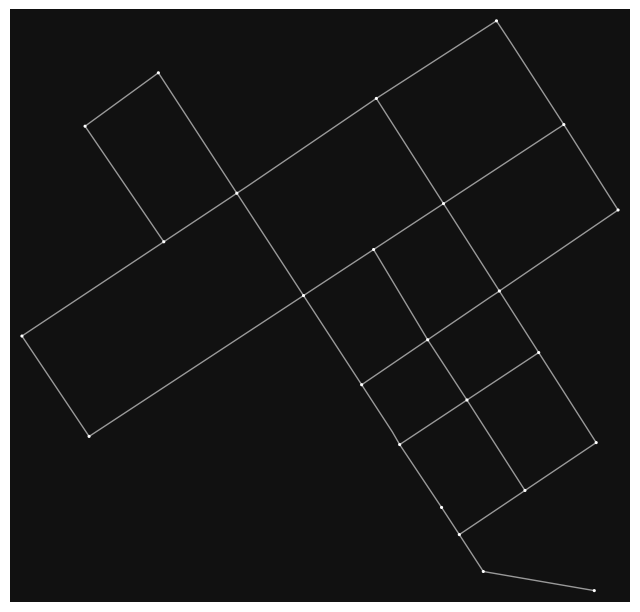

(<Figure size 800x800 with 1 Axes>, <Axes: >)

In [6]:
# change other way try

df = dataframes["df_L1830_1024"]
center_lat = df["lat"].mean()
center_lon = df["lon"].mean()

# network in 200 meters radius from center
G = graph_from_point((center_lat, center_lon), dist=200, network_type="drive")


ox.plot_graph(G, node_size=5)


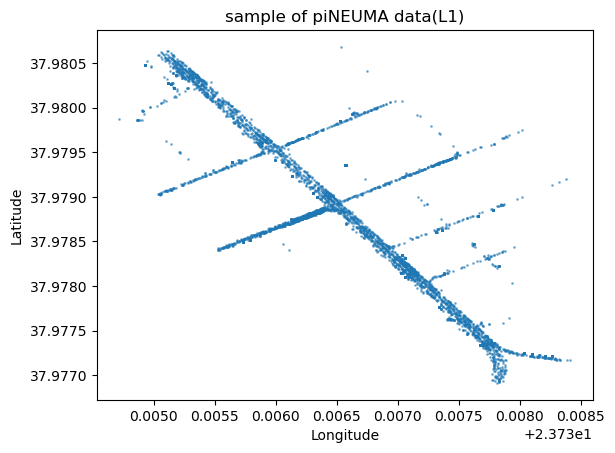

In [7]:
# 5000 random points
sample_df = df.sample(n=5000)  
plt.scatter(sample_df["lon"], sample_df["lat"], s=1, alpha=0.5)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("sample of piNEUMA data(L1)")
plt.show()

In [8]:
nodes, edges = ox.graph_to_gdfs(G, nodes=True, edges=True)

# to build intersections dictionary
intersections = {}
for node_id, row in nodes.iterrows():
    connected_nodes = list(G.adj[node_id].keys()) 
    intersections[str(node_id)] = {
        "lat": row["y"],
        "lon": row["x"],
        "connected_road": [f"{node_id}_{nbr}" for nbr in connected_nodes]
    }

# to build road segments dictionary
road_segments = {}
for u, v, k, data in G.edges(keys=True, data=True):
    if "geometry" in data:
        coords = list(data["geometry"].coords)
    else:
        coords = [
            (nodes.loc[u]["x"], nodes.loc[u]["y"]),
            (nodes.loc[v]["x"], nodes.loc[v]["y"])
        ]

    coords_latlon = [[lat, lon] for lon, lat in coords]  
    road_id = f"{u}_{v}_{k}"

    road_segments[road_id] = {
        "coords": coords_latlon,
        "connected_intersections": [str(u), str(v)]
    }

# for check
print(f"Intersections: {len(intersections)}")
print(f"Road segments: {len(road_segments)}")

Intersections: 25
Road segments: 35


In [9]:
# save for reuse
with open("intersections_location1.json", "w") as f:
    json.dump(intersections, f, indent=2)

with open("road_segments_location1.json", "w") as f:
    json.dump(road_segments, f, indent=2)

In [21]:
gps_points = gpd.GeoSeries(
    [Point(lon, lat) for lon, lat in zip(df["lon"], df["lat"])],
    crs="EPSG:4326"
)
point_gdf = gpd.GeoDataFrame(df.copy(), geometry=gps_points)
edges = ox.graph_to_gdfs(G, nodes=False, edges=True).reset_index()
edges["road_id"] = edges.apply(lambda row: f"{row['u']}_{row['v']}_{row['key']}", axis=1)

road_gdf = edges[["road_id", "geometry"]].copy()
point_gdf = point_gdf.to_crs(epsg=3857)
road_gdf = road_gdf.to_crs(epsg=3857)

point_gdf = point_gdf[point_gdf.geometry.notnull()].copy()
road_gdf = road_gdf[road_gdf.geometry.notnull()].copy()


In [22]:
road_sindex = road_gdf.sindex
assigned_ids = []

for pt in tqdm(point_gdf.geometry, desc="Matching using true geometric distance"):
    possible_matches_index = list(road_sindex.intersection(pt.buffer(50).bounds))
    candidates = road_gdf.iloc[possible_matches_index]

    if not candidates.empty:
        distances = candidates.geometry.distance(pt)
        nearest_idx = distances.idxmin()
        assigned_ids.append(road_gdf.loc[nearest_idx, "road_id"])
    else:
        assigned_ids.append(None)

point_gdf["road_id"] = assigned_ids

# debug check
print("number of unique road segments matched:", point_gdf["road_id"].nunique())
print(point_gdf["road_id"].value_counts().head(10))


Matching using true geometric distance: 100%|█| 1446887/1446887 [03:31<00:00, 68


number of unique road segments matched: 30
road_id
250691723_250691755_0      213869
10174555843_300400470_0    174393
250692359_250691739_0      148997
300400470_250691755_0      122531
6220792260_250692409_0      95803
250691755_250692359_0       92957
10174555843_653971690_0     87015
250691739_250691794_0       82398
10134034294_300400470_0     74602
250691793_6220792260_0      68390
Name: count, dtype: int64


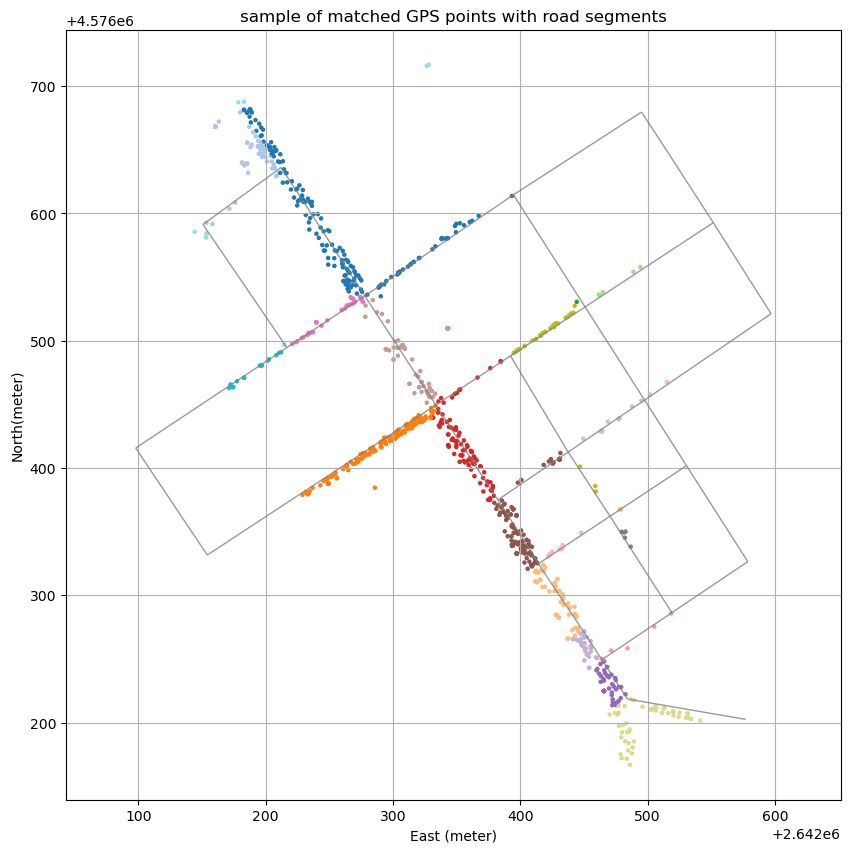

In [25]:
# visul result to check and verify
sample = point_gdf.sample(n=1000, random_state=42).copy()
sample["road_id"] = sample["road_id"].astype(str)

# plot roads and gps points
fig, ax = plt.subplots(figsize=(10, 10))
road_gdf.plot(ax=ax, linewidth=1, edgecolor="gray", alpha=0.8)
sample.plot(ax=ax, column="road_id", cmap="tab20", markersize=5, legend=False)

plt.title("sample of matched GPS points with road segments")
plt.xlabel("East (meter)")
plt.ylabel("North(meter)")
plt.axis("equal")
plt.grid(True)
plt.show()

In [27]:
point_gdf["track_id"] = pd.to_numeric(point_gdf["track_id"], errors="coerce")
point_gdf["road_id"] = point_gdf["road_id"].astype(str)
road_summary = (
    point_gdf.groupby("road_id")
    .agg(
        avg_speed=("speed", "mean"),
        vehicle_count=("track_id", "nunique")
    )
    .reset_index()
)

top_segments = road_summary.sort_values("vehicle_count", ascending=False).head(10)



print("top 10 road segments by vehicle count:")
print(top_segments)

top 10 road segments by vehicle count:
                    road_id  avg_speed  vehicle_count
8     250691755_250692359_0  30.739563            554
12    250691794_250691793_0  25.731730            542
4     250691739_250691794_0  26.146615            532
11   250691793_6220792260_0  19.114152            506
27   6220792260_250692409_0  17.150514            503
1   10174555843_300400470_0  24.724275            474
14    250692359_250691739_0  12.622211            470
3     250691723_250691755_0   9.105988            411
16    300400470_250691755_0  20.323332            398
30                     None  31.046071            269


In [29]:
# retry for sperate unmatch point to make None will not in data cal
point_gdf["track_id"] = pd.to_numeric(point_gdf["track_id"], errors="coerce")
point_gdf["road_id"] = point_gdf["road_id"].astype(str)

valid_points = point_gdf[point_gdf["road_id"].notnull() & (point_gdf["road_id"] != "None")]
road_summary = (
    valid_points.groupby("road_id")
    .agg(
        avg_speed=("speed", "mean"),
        vehicle_count=("track_id", "nunique")
    )
    .reset_index()
)

top_segments = road_summary.sort_values("vehicle_count", ascending=False).head(10)


print("top 10 road segments by vehicle count:")
print(top_segments)

unmatched_count = point_gdf["road_id"].isna().sum() + (point_gdf["road_id"] == "None").sum()
print(f"\n number of unmatched points (make these excluded from aggregation): {unmatched_count}")

top 10 road segments by vehicle count:
                    road_id  avg_speed  vehicle_count
8     250691755_250692359_0  30.739563            554
12    250691794_250691793_0  25.731730            542
4     250691739_250691794_0  26.146615            532
11   250691793_6220792260_0  19.114152            506
27   6220792260_250692409_0  17.150514            503
1   10174555843_300400470_0  24.724275            474
14    250692359_250691739_0  12.622211            470
3     250691723_250691755_0   9.105988            411
16    300400470_250691755_0  20.323332            398
17    300400470_653971685_0  15.841126            269

 number of unmatched points (make these excluded from aggregation): 3151


number of road segments: 35
unique road IDs: 35
LineString    35
Name: count, dtype: int64


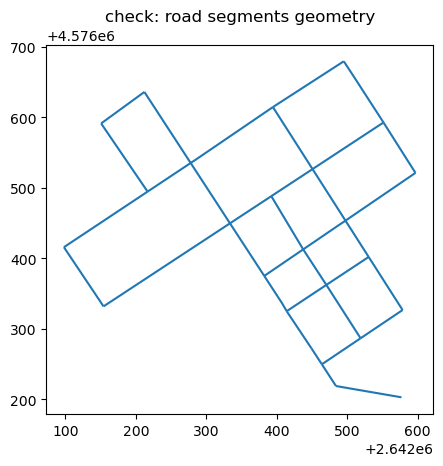

In [31]:
#printout for debug
print("number of road segments:", len(road_gdf))
print("unique road IDs:", road_gdf["road_id"].nunique())
print(road_gdf.geometry.geom_type.value_counts())
road_gdf.plot()
plt.title("check: road segments geometry")
plt.show()

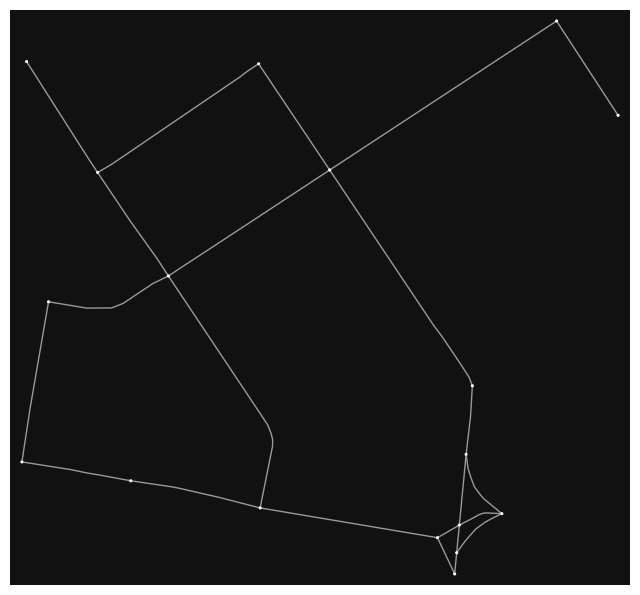

(<Figure size 800x800 with 1 Axes>, <Axes: >)

In [71]:
# try other location (loc 2 to loc 7)
dfL2 = dataframes["df_L2830_1024"]
center_lat = dfL2["lat"].mean()
center_lon = dfL2["lon"].mean()

# network in 200 meters radius from center
G = graph_from_point((center_lat, center_lon), dist=200, network_type="drive")


ox.plot_graph(G, node_size=5)

In [73]:
nodes, edges = ox.graph_to_gdfs(G, nodes=True, edges=True)

# to build intersections dictionary
intersections = {}
for node_id, row in nodes.iterrows():
    connected_nodes = list(G.adj[node_id].keys()) 
    intersections[str(node_id)] = {
        "lat": row["y"],
        "lon": row["x"],
        "connected_road": [f"{node_id}_{nbr}" for nbr in connected_nodes]
    }

# to build road segments dictionary
road_segments = {}
for u, v, k, data in G.edges(keys=True, data=True):
    if "geometry" in data:
        coords = list(data["geometry"].coords)
    else:
        coords = [
            (nodes.loc[u]["x"], nodes.loc[u]["y"]),
            (nodes.loc[v]["x"], nodes.loc[v]["y"])
        ]

    coords_latlon = [[lat, lon] for lon, lat in coords]  
    road_id = f"{u}_{v}_{k}"

    road_segments[road_id] = {
        "coords": coords_latlon,
        "connected_intersections": [str(u), str(v)]
    }

# for check
print(f"Intersections: {len(intersections)}")
print(f"Road segments: {len(road_segments)}")

Intersections: 18
Road segments: 23


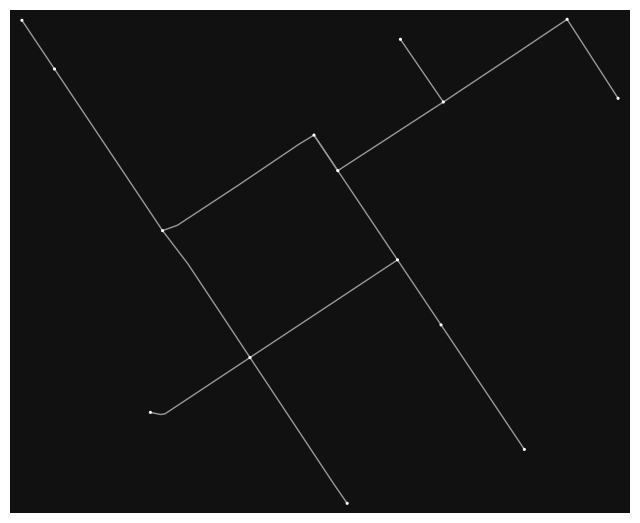

(<Figure size 800x800 with 1 Axes>, <Axes: >)

In [57]:
dfL3 = dataframes["df_L3830_1024"]
center_lat = dfL3["lat"].mean()
center_lon = dfL3["lon"].mean()

# network in 200 meters radius from center
G = graph_from_point((center_lat, center_lon), dist=200, network_type="drive")


ox.plot_graph(G, node_size=5)

In [76]:
nodes, edges = ox.graph_to_gdfs(G, nodes=True, edges=True)

# to build intersections dictionary
intersections = {}
for node_id, row in nodes.iterrows():
    connected_nodes = list(G.adj[node_id].keys()) 
    intersections[str(node_id)] = {
        "lat": row["y"],
        "lon": row["x"],
        "connected_road": [f"{node_id}_{nbr}" for nbr in connected_nodes]
    }

# to build road segments dictionary
road_segments = {}
for u, v, k, data in G.edges(keys=True, data=True):
    if "geometry" in data:
        coords = list(data["geometry"].coords)
    else:
        coords = [
            (nodes.loc[u]["x"], nodes.loc[u]["y"]),
            (nodes.loc[v]["x"], nodes.loc[v]["y"])
        ]

    coords_latlon = [[lat, lon] for lon, lat in coords]  
    road_id = f"{u}_{v}_{k}"

    road_segments[road_id] = {
        "coords": coords_latlon,
        "connected_intersections": [str(u), str(v)]
    }

# for check
print(f"Intersections: {len(intersections)}")
print(f"Road segments: {len(road_segments)}")

Intersections: 18
Road segments: 23


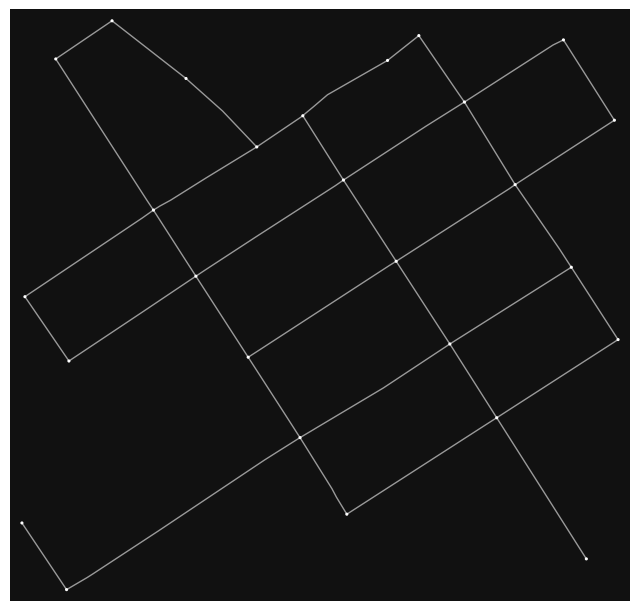

(<Figure size 800x800 with 1 Axes>, <Axes: >)

In [78]:
dfL4 = dataframes["df_L4830_1024"]
center_lat = dfL4["lat"].mean()
center_lon = dfL4["lon"].mean()

# network in 200 meters radius from center
G = graph_from_point((center_lat, center_lon), dist=200, network_type="drive")


ox.plot_graph(G, node_size=5)

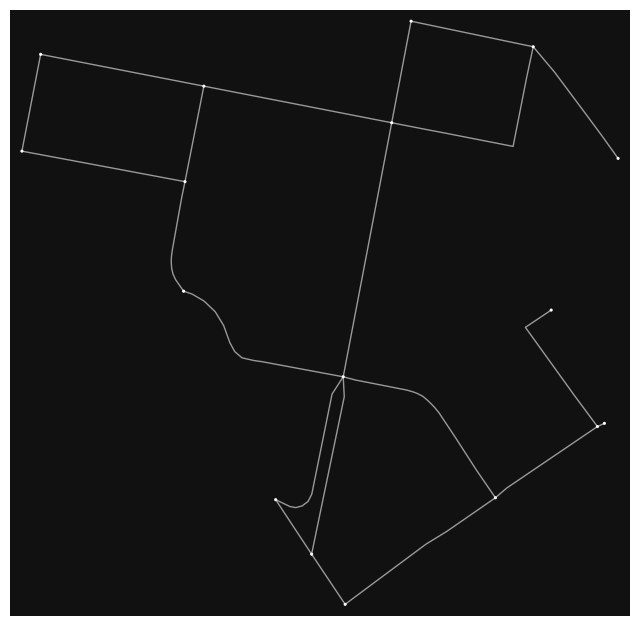

(<Figure size 800x800 with 1 Axes>, <Axes: >)

In [61]:
dfL5 = dataframes["df_L5830_1024"]
center_lat = dfL5["lat"].mean()
center_lon = dfL5["lon"].mean()

# network in 200 meters radius from center
G = graph_from_point((center_lat, center_lon), dist=200, network_type="drive")


ox.plot_graph(G, node_size=5)

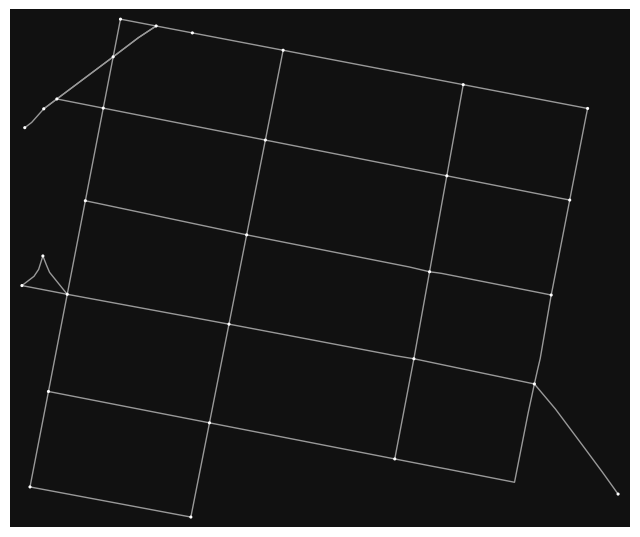

(<Figure size 800x800 with 1 Axes>, <Axes: >)

In [65]:
dfL6 = dataframes["df_L6830_1024"]
center_lat = dfL6["lat"].mean()
center_lon = dfL6["lon"].mean()

# network in 200 meters radius from center
G = graph_from_point((center_lat, center_lon), dist=200, network_type="drive")


ox.plot_graph(G, node_size=5)

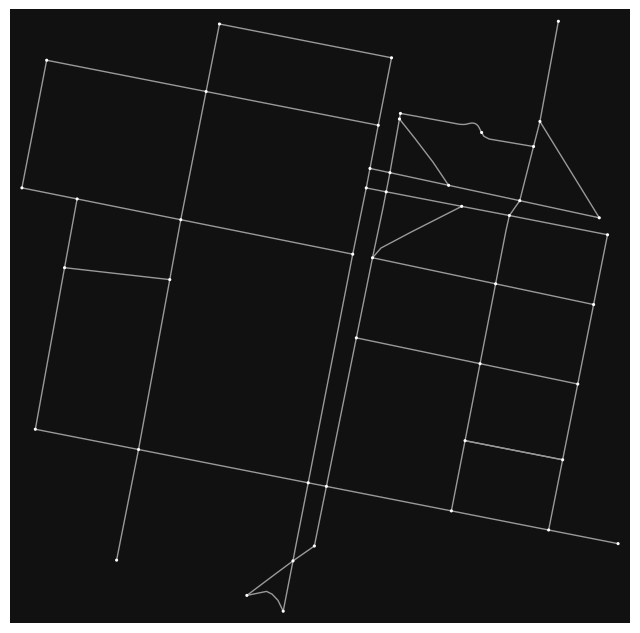

(<Figure size 800x800 with 1 Axes>, <Axes: >)

In [69]:
dfL7 = dataframes["df_L7830_1024"]
center_lat = dfL7["lat"].mean()
center_lon = dfL7["lon"].mean()

# network in 200 meters radius from center
G = graph_from_point((center_lat, center_lon), dist=200, network_type="drive")


ox.plot_graph(G, node_size=5)

In [86]:
# function to apply the all location based on need
def process_location_dataframe(df, location_label, radius=200):

    center_lat = df["lat"].mean()
    center_lon = df["lon"].mean()
    G = ox.graph_from_point((center_lat, center_lon), dist=radius, network_type="drive")

    # convert graph to GeoDataFrames
    nodes, edges = ox.graph_to_gdfs(G, nodes=True, edges=True)
    edges = edges.reset_index()
    edges["road_id"] = edges.apply(lambda row: f"{row['u']}_{row['v']}_{row['key']}", axis=1)

    road_gdf = edges[["road_id", "geometry"]].copy().to_crs(epsg=3857)

    # GPS points to GeoDataFrame
    gps_points = gpd.GeoSeries([Point(lon, lat) for lon, lat in zip(df["lon"], df["lat"])], crs="EPSG:4326")
    point_gdf = gpd.GeoDataFrame(df.copy(), geometry=gps_points).to_crs(epsg=3857)
    point_gdf = point_gdf[point_gdf.geometry.notnull()].copy()

    # spatial join via geometric distance
    road_sindex = road_gdf.sindex
    assigned_ids = []

    for pt in tqdm(point_gdf.geometry, desc=f"Matching {location_label}"):
        possible_matches_idx = list(road_sindex.intersection(pt.buffer(50).bounds))
        candidates = road_gdf.iloc[possible_matches_idx]

        if not candidates.empty:
            distances = candidates.geometry.distance(pt)
            nearest_idx = distances.idxmin()
            assigned_ids.append(road_gdf.loc[nearest_idx, "road_id"])
        else:
            assigned_ids.append(None)

    point_gdf["road_id"] = assigned_ids

    # stat summary
    point_gdf["track_id"] = pd.to_numeric(point_gdf["track_id"], errors="coerce")
    point_gdf["road_id"] = point_gdf["road_id"].astype(str)
    valid_points = point_gdf[point_gdf["road_id"].notnull() & (point_gdf["road_id"] != "None")]

    road_summary = (
        valid_points.groupby("road_id")
        .agg(avg_speed=("speed", "mean"), vehicle_count=("track_id", "nunique"))
        .reset_index()
    )

    top_segments = road_summary.sort_values("vehicle_count", ascending=False).head(10)

    unmatched_count = point_gdf["road_id"].isna().sum() + (point_gdf["road_id"] == "None").sum()

    # visualization
    sample = point_gdf.sample(n=1000, random_state=42).copy()
    sample["road_id"] = sample["road_id"].astype(str)

    fig, ax = plt.subplots(figsize=(10, 10))
    road_gdf.plot(ax=ax, linewidth=1, edgecolor="gray", alpha=0.8)
    sample.plot(ax=ax, column="road_id", cmap="tab20", markersize=5, legend=False)
    plt.title(f"Sample of matched GPS points ({location_label})")
    plt.xlabel("East (meter)")
    plt.ylabel("North (meter)")
    plt.axis("equal")
    plt.grid(True)
    plt.show()

    print(f"Top segments ({location_label}):")
    print(top_segments)
    print(f"\n Number of unmatched points: {unmatched_count}")


Matching L2: 100%|██████████████████| 3761480/3761480 [09:03<00:00, 6925.25it/s]


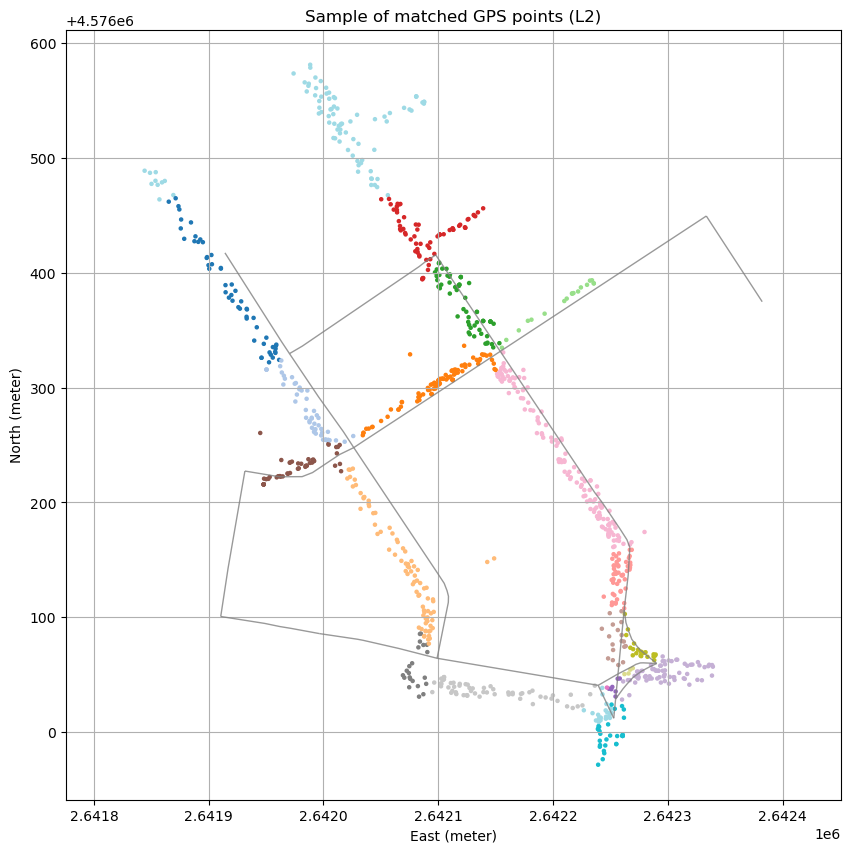

Top segments (L2):
                   road_id  avg_speed  vehicle_count
4    250691723_250691724_0  26.472388           1064
2    250691670_250691723_0   8.340114            984
13  3339821648_250691723_0  22.571189            937
6    250691724_250691669_0  24.837961            920
7   250691827_3339821648_0  23.902885            903
11  2511789008_250691827_0  27.726501            881
14    42240105_250691272_0  21.510741            822
19  954712428_7384331753_0  15.443147            798
18   954712428_250691847_0  12.470672            780
9    250691847_954712407_0  10.439310            774

 Number of unmatched points: 329126


In [88]:
# test on loc 2 (my laptop runtime for tis code 10 min)
process_location_dataframe(dataframes["df_L2830_1024"], "L2", radius=200)